<a href="https://colab.research.google.com/github/rastri-dey/Ground-up-implementations-ML-algorithms-/blob/main/notebooks/CNN_cifar_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description

Building an image classification model from CIFAR10 dataset for 10 different classes of images

**ML Algorithm**: Deep Convolutional Neural Network <br>
**Dataset**: CIFAR10 <br>
**Framework**: PyTorch

## Import the libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import time
import os

## Check the device enabled

In [ ]:
'''
Output:
GPU device enabled
Updated Torch version
'''
print(torch.__version__)

# Checks if a CUDA-capable GPU is detected and accessible by PyTorch
if torch.cuda.is_available():
  device = torch.device("cuda:0") # Computations to be performed on GPU
else:
  device = torch.device("cpu") # Computations to be performed on CPU

print(device)

2.8.0+cu126
cuda:0


## Get the Dataset - CIFAR10

In [ ]:
'''
Output: Image Tensors for Training and Validation datasets from CIFAR10
'''
folder = "data"
cifar10_train = datasets.CIFAR10(folder, train = True, download = True, transform = transforms.ToTensor())
cifar10_val = datasets.CIFAR10(folder, train = False, download = True, transform = transforms.ToTensor())
# transforms.ToTensor() converts the pixels from PIL (0,255) range values to tensors of (0,1) range values

100%|██████████| 170M/170M [00:03<00:00, 45.6MB/s]


## Normalize the Dataset

In [ ]:
'''
Output: Normalized Image Tensors
'''
print(f"Each image dimension in CIFAR10: {cifar10_train[0][0].shape}") # cifar10_train contains images, labels: Here images has the shape: [C,H,W]

imgs = torch.stack([img for img, _ in cifar10_train], dim=3)
print(f"Stack all the images: {imgs.shape}") # [C, H, W, N]

imgs_flat = imgs.view(3, -1)
print(f"Flatten all the images across each channel: {imgs_flat.shape}") # [C, H*W*N]

# We need the Mean & Standard Deviation of all images from CIFAR10 train along the channels
# Mean through all images across R, G and B channel
mu = imgs_flat.mean(dim=1)

# Standard Deviation through all images across R, G and B channel
sigma = imgs_flat.std(dim=1)

# Normalized Training Image Tensors Dataset
cifar10_train = datasets.CIFAR10(
    folder,
    train = True,
    download = False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mu, sigma)
    ])
)

# Normalized Validation Image Tensors Dataset
cifar10_val = datasets.CIFAR10(
    folder,
    train = False,
    download = False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mu, sigma)
    ])
)

Each image dimension in CIFAR10: torch.Size([3, 32, 32])
Stack all the images: torch.Size([3, 32, 32, 50000])
Flatten all the images across each channel: torch.Size([3, 51200000])


## Define the Model - CNN

> img_batch -> conv1 -> activation -> maxPool -> conv2 -> activation -> maxPool -> fc1 -> activation -> fc2 -> nclasses

### Process:

1. Each **image** is handled independently `[C, H, W]` ->
2. **Conv1** has 16 filters each of kernel_size (3,3) and padding = kernel_size // 2 `[16, H, W]` ->
3. **Activation** Layer doesn't change the dimension ->
4. **Max Pooling** of Kernel size = (2,2) will reduce the spatial dimensions to H/2, W/2 `[16, H/2, W/2]` ->
5. **Conv2** layer has 8 filters each of kernel_size (3,3) and padding = kernel_size // 2 `[8, H/2, W/2]` ->
6. **Activation** Layer doesn't change the dimension ->
7. **Max Pooling** of Kernel size = (2,2) will reduce the spatial dimensions to H/4, W/4 `[8, H/4, W/4]` ->
8. **Fully Connected** Dense Layer [Flatten the img here from `[8, H/4, W/4]` to 1D `[8 * H/4 * W/4]`, hidden units] ->
9. **Activation** Layer doesn't change the dimension ->
10. **Fully Connected** Dense Layer `[hidden units, nclasses] `->
11. The **output** nclasses is in logits having dimension as `[Batch_size, nclasses]` where each image in batch has 10 logits which is the raw output

Note:  

*   Add 1 extra dimension in the beginning for all this, as Pytorch accepts inputs in batches. So, if batch_size is 64, then that 1 entire batch of 64 images, is handled from the input to the output and backwards during training the loop.
*   The FC1, FC2 layers are also `[batch_size, 1D vector]`



In [ ]:
'''
Input: Image Batch (Batch_size, C, H, W)
Output: Classes
'''
'''
The output of conv1 layer will have 16 channels and changes in spatial dimensions
due to kernel size, padding and max pooling
The output of conv2 layer will have the channel size as 8
When we define padding = kernel_size/2, then the height, width output is of
same dimensions as height, width input
'''
class NeuralNet(nn.Module):
  def __init__(self, img, nclasses, nchannels=16, nhidden=32, kernel_size=3):
    super().__init__()
    C, H, W = img.shape
    self.conv1 = nn.Conv2d(C, nchannels, kernel_size = kernel_size, padding = kernel_size // 2)
    self.conv2 = nn.Conv2d(nchannels, nchannels//2, kernel_size = kernel_size, padding = kernel_size // 2)
    self.flat1 = nchannels//2 * H//4 * W//4
    self.fc1 = nn.Linear(nchannels//2 * H//4 * W//4, nhidden)
    self.fc2 = nn.Linear(nhidden, nclasses)


  def forward(self, x):
    out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)   # MaxPool output from Conv1
    out = F.max_pool2d(torch.tanh(self.conv2(out)), 2) # MaxPool output from Conv2
    out = out.view(-1, self.flat1)                     # Changing the output from 3D to 1D for Fully Connected Layer
    out = torch.tanh(self.fc1(out))                    # 1D of input size nchannels//2 * H//4 * W//4 -> output size nhidden units & Add activation layer
    out = self.fc2(out)                                # Add fully Connected layer for output size nclasses
    return out


## Training Loop

### Operating in GPU:
**Model** & **Data** both requires to be on **GPU**.
The torch.utils.data.DataLoader is an iterator.
The data loading and batch creation process happens on the CPU by default.
So, imgs, labels when loaded are explicitly required to move to GPU within the training loop. We can not put the whole train_loader in GPU, its merely an iterator, not saving any memory for data.

### Model Parameters (Weights & Biases):
p.pow(2).sum() calculates the sum of weights and biases within the tensor for every specific layer
The outer sum takes to total sum of all weights & biases tensors

**For Convolutional Layers**, the weights have spatial dimnesion of size (Kernel_height, Kernel_width)
and the channel dimension automatically takes the input image channel dimension,
so the weight tensor with one filter has the shape of `[img_channel, Kernel_height, Kernel_width]`
For all the filters included, the shape of **weight tensor** for a specific Convolutional Layer is:
`[out_channel, img_channel, Kernel_height, Kernel_width]`

The **bias tensor** for the specific Convolutional Layer has the shape: `[out_channel]`

For **Fully Connected Layer**, the **weight tensor** for a specfic layer has the shape `[out_features, in_features]`
The **bias tensor** for the specific Fully Connected Layer has the shape: `[out_features]`

In [ ]:
def training(n_epochs, train_loader, model, loss_fn, optimizer, l_regularizer):
  for epoch in range(n_epochs):
    loss_epoch = 0
    time_start = time.time()
    for imgs, labels in train_loader:
      imgs = imgs.to(device=device)
      labels = labels.to(device=device)
      outputs = model(imgs)       # Forward Pass, Outputs has shape of [batch_size, logits]
      loss = loss_fn(outputs, labels)

      # We want to do L2 regularilization to avoid overfitting
      l2_norm = sum(p.pow(2).sum() for p in model.parameters())
      loss = loss + l2_norm * l_regularizer

      # By default the optimizer stores the gradient, so it needs to be cleared
      # before calculating the gradients for the current batch
      optimizer.zero_grad()

      loss.backward()            # Calculate the loss backwards

      optimizer.step()           # Updates the model's parameters: weights & bias

      loss_epoch += loss.item()  # Accumulate all the losses for all batches in one epoch

    print(f"Epoch: {epoch+1}: {time.time()-time_start}, Train Loss: {loss_epoch/len(train_loader)}")

## Train the model with Dataset in batches

In [ ]:
img, label = cifar10_train[0]
img_t = img.unsqueeze(0)
img_batch = img_t.to(device=device)

train_loader = torch.utils.data.DataLoader(cifar10_train, batch_size = 64, shuffle = True) # Each batch has 64 images
model = NeuralNet(img_batch[0], nclasses = 10).to(device = device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 1e-2)

time_start = time.time()

training(
    n_epochs = 100,
    train_loader = train_loader,
    model = model,
    loss_fn = loss_fn,
    optimizer = optimizer,
    l_regularizer = 0.001
)
print(f"Training Time: {time.time()-time_start}")

Epoch: 1: 13.752796649932861, Train Loss: 2.041419508816946
Epoch: 2: 13.633259773254395, Train Loss: 1.7532448020127729
Epoch: 3: 17.243038415908813, Train Loss: 1.6023336871505698
Epoch: 4: 13.096555709838867, Train Loss: 1.5109370957555064
Epoch: 5: 13.091575860977173, Train Loss: 1.4335266295296456
Epoch: 6: 12.86649751663208, Train Loss: 1.3723683439557204
Epoch: 7: 12.839942932128906, Train Loss: 1.3290294515507302
Epoch: 8: 13.512048721313477, Train Loss: 1.294980702878874
Epoch: 9: 12.88523244857788, Train Loss: 1.2686441303671474
Epoch: 10: 12.799773931503296, Train Loss: 1.2423861409392198
Epoch: 11: 12.81939148902893, Train Loss: 1.2218632095152764
Epoch: 12: 13.12855577468872, Train Loss: 1.205942946398045
Epoch: 13: 13.042568683624268, Train Loss: 1.189327008355304
Epoch: 14: 12.749423027038574, Train Loss: 1.1763396829442905
Epoch: 15: 12.6677405834198, Train Loss: 1.163078940280563
Epoch: 16: 12.743534088134766, Train Loss: 1.15259007069156
Epoch: 17: 12.695825815200806,

## Calculate the accuracy

In [ ]:
def accuracy(loader, model):
  correct = 0
  total = 0
  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device = device)
      labels = labels.to(device = device)
      outputs = model(imgs)                    # Outputs has shape of [batch_size, logits]
      _, predicted = torch.max(outputs, dim=1) # We just want the index for the class, not the max logit value
      correct += int((predicted==labels).sum())  # Total correct outputs in one batch, then sum all the correct for all batches
      total += labels.shape[0]                 # Total data samples in currect batch, sum of all the data samples from all batches

  accuracy = correct/total

  return accuracy

# Load validation data through DataLoader
val_loader = torch.utils.data.DataLoader(cifar10_val, batch_size = 64, shuffle = False)
train_accuracy = accuracy(train_loader, model)  # Training Accuracy
val_accuracy = accuracy(val_loader, model)      # Validation Accuracy

print(f"Training Accuracy: {train_accuracy}, Validation Accuracy = {val_accuracy}")

Training Accuracy: 0.67544, Validation Accuracy = 0.6327


## Save the Model

* The notebook (this one) is stored inside the google drive of the user. This is permanent unless the user wants to delete it.
* While running the notebook within the Colab runtime, it temporarily allocates your session to a virtual machine, where the notebook is loaded and runs during the current runtime session.
*   During this current runtime, any folder like "data" here is created to save the datasets is stored within the directory called `/contents/`data within the allocated virtual machine by Colab
*   Once the current runtime session ends, the colab deletes anything from the directory: `/contents/`

*   To save the model, the standard process is to mount your google drive within the colab runtime directory: `/contents/drive/`
*   When we mount the google drive within Colab, then after the current runtime session ends, everything gets deleted except the mounted drive within Colab: `/contents/drive/`


*   This happens because the files you saved through the `/content/drive` were never actually on that temporary file system in the virtual machine. They were always stored in your persistent Google Drive storage. The `/content/drive` path was just a way to access them from within the temporary machine.
*   Think of it like plugging in an external hard drive (Google Drive) to a temporary computer (Colab runtime). When you unplug the hard drive (session ends), the files on the hard drive are still there, even though the temporary computer's internal storage is deleted. The computer was just a means to access `/content/drive` folder once the external hard drive is "mounted"  


*   The actual model is saved within the google drive
*   Create a folder like:  `/content/drive/MyDrive/` within google drive to get all the models organized within MyDrive:


```
save_path_in_drive = "/content/drive/MyDrive/my_ml_models/cifar10_pytorch.pt"
torch.save(model.state_dict(), save_path_in_drive)
```















In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

save_dir = "/content/drive/MyDrive/my_ml_models"
os.makedirs(save_dir, exist_ok=True) #!mkdir -p "{save_dir}"

save_path = os.path.join(save_dir, "cifar10_pytorch.pt")

torch.save(model.state_dict(), save_path) # Save the model

print(f"Model saved to: {save_path}")

Mounted at /content/drive
Model saved to: /content/drive/MyDrive/my_ml_models/cifar10_pytorch.pt


## Load the saved Model


*   Define a new instance of the model from NeuralNet class
*   Load the saved Parameters from the provided google drive location within the model



In [ ]:
# Here save_path is the path in user's google drive
loaded_model = NeuralNet(img_batch[0], nclasses = 10).to(device = device) # Define a new instance of the neuralNet class
loaded_model.load_state_dict(torch.load(save_path, map_location=device))

# Set the model to evaluation mode
loaded_model.eval()

NeuralNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=512, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)

## Test the results

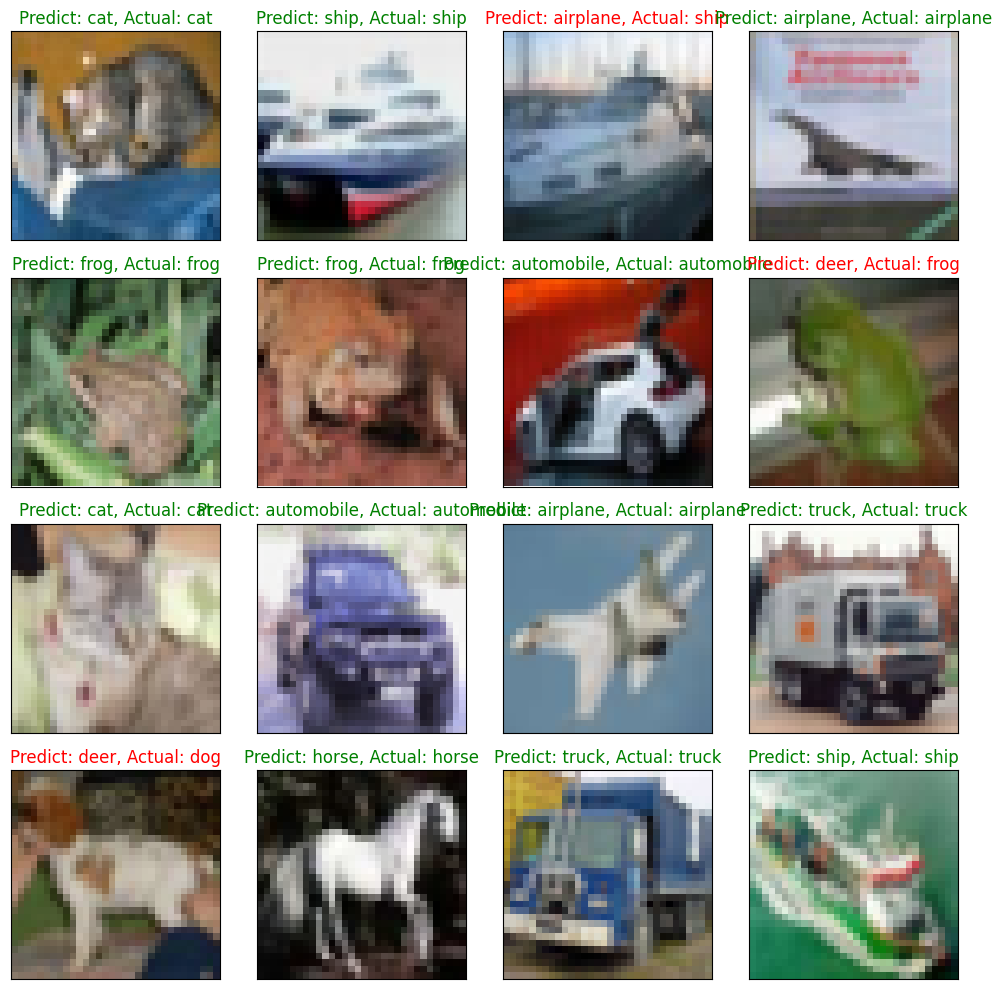

In [ ]:
# Get a single batch of images and labels from the validation loader
imgs, labels = next(iter(val_loader))
'''
Here, while the numerical output of predictions might be the same,
the performance (speed and memory usage) will be better with torch.no_grad()
'''
# Make predictions
with torch.no_grad():
      imgs = imgs.to(device = device)          # 1 batch
      labels = labels.to(device = device)      # 1 batch
      outputs = model(imgs)
      _, predicted = torch.max(outputs, dim=1)

# Class names for CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualize the results
fig = plt.figure(figsize=(10,10))
for i in range(min(16, len(imgs))):
    ax = fig.add_subplot(4, 4, i+1, xticks = [], yticks = [])
    # Unnormalize the images
    # Matplotlib accepts the images in format: [H, W, C]
    img = imgs[i].permute(1,2,0) * sigma.to(device=device) + mu.to(device=device)
    ax.imshow(img.cpu()) # Move the image back to CPU for plotting
    color = "green" if predicted[i]==labels[i] else "red"
    ax.set_title(f"Predict: {class_names[predicted[i]]}, Actual: {class_names[labels[i]]}", color = color)

plt.tight_layout()
plt.show()